# Find DCM motifs in genes of interest

I got genes differentially expressed between two stages of development, and considering only cells annotated as neural, progenitors or differentiated (in our data).

### User Parameters

In [1]:
# Considering that DCM methylates both strands or just the strand on which the pol-II is elongating? 
case = 'case1'

### Set-up

In [2]:
import pandas as pd
import pyranges as pr
import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
def load_motif_fastaregexfinder_results(motif_file):
    columns = ["Chromosome", "Start", "End", "Motif_name", "Strand", "Motif_Matched"]
    motifs = pd.read_csv(motif_file, sep="\t", names=columns)
    motifs["second_idx"] = range(1, len(motifs) + 1)
    motifs["Chromosome"] = motifs["Chromosome"].astype(str)
    return motifs

In [4]:
# Scaffolds decrease confidence, we filter them out
def filter_df(df):
    resolved_chr = [f'{i}' for i in range(1,25+1)]
    resolved_chr.append('MT')
    return df[df["Chromosome"].isin(resolved_chr)]

In [5]:
if case=='case1':
    strandedness_=False
elif case=="case2":
    strandedness_='same'
else:
    raise NameError('Provide a case number')

# **CODE CONTENT**

### Import the marker genes as a dataframe

In [1]:
markers_file = "/files_genes_of_interest.csv"
markers = pd.read_csv(markers_file)
markers.head()

NameError: name 'pd' is not defined

In [7]:
markers = markers.dropna(axis=1, how='all')
markers = markers.drop(['neural_mostly_expressed_in_5dpf_up'], axis =1)
markers.head()

,neural_mostly_expressed_in_2dpf_up,neural_mostly_expressed_in_5dpf_down,progenitor_mostly_expressed_in_2dpf_up,progenitor_mostly_expressed_in_5dpf_down,differentiated_mostly_expressed_in_2dpf_up,differentiated_mostly_expressed_in_5dpf_down
0,hoxb6b,ccsapb,otpa,kif1b,hoxa9a,pdap1b
1,hoxa9a,nr2c2,si:ch211-152f23.5,BX936337.1,hoxb6b,ypel3
2,gfap,suclg2,hbbe3,larp1b,hoxd9a,ubald1a
3,hbbe3,slc25a18,si:dkey-9c18.3,lpin2,hbbe3,zgc:110339
4,nkx6.1,tsc22d1,otpb,tspan7b,gdf11,dnmt3ab


"neural_mostly_expressed_in_5dpf_down" :
These genes are significantly downregulated in 2 dpf cells compared to cells 5dpf (negative log FC indicates lower expression in the first group).
The percentage of cells where the gene is detected (pct.2 > pct.1) indicates that more cells in group 2 express these genes than in group 1.

In [8]:
#condition = 'neural_mostly_expressed_in_2dpf_up'
#condition = 'neural_mostly_expressed_in_5dpf_down'
#condition = 'progenitor_mostly_expressed_in_2dpf_up'
#condition = 'progenitor_mostly_expressed_in_5dpf_down'
#condition = 'differentiated_mostly_expressed_in_2dpf_up'
condition = 'differentiated_mostly_expressed_in_5dpf_down'

### Call Ensembl Rest API to get information about those marker genes

In [9]:
# Request the genes information from Ensembl

import requests, sys

server = "https://rest.ensembl.org"
ext = "/lookup/symbol/danio_rerio"
headers={ "Content-Type" : "application/json", "Accept" : "application/json"}
genes_list = list(markers[f'{condition}'])
#keep only the first 20 ones to have something readable
genes_list = genes_list[:20]
# Make sure genes are string and not NaN
genes_list = [str(gene) for gene in genes_list if pd.notna(gene)]
payload = {"symbols" : genes_list}
r = requests.post(server+ext, headers=headers, json=payload)
    
if not r.ok:
    r.raise_for_status()
    sys.exit()
         
decoded = r.json()
print(repr(decoded))

{'ypel3': {'id': 'ENSDARG00000055510', 'species': 'danio_rerio', 'display_name': 'ypel3', 'seq_region_name': '3', 'object_type': 'Gene', 'version': 7, 'db_type': 'core', 'strand': -1, 'end': 26191960, 'canonical_transcript': 'ENSDART00000113843.5', 'logic_name': 'ensembl_havana_gene', 'biotype': 'protein_coding', 'start': 26186153, 'description': 'yippee-like 3 [Source:ZFIN;Acc:ZDB-GENE-030516-4]', 'source': 'ensembl_havana', 'assembly_name': 'GRCz11'}, 'pik3r1': {'display_name': 'pik3r1', 'object_type': 'Gene', 'seq_region_name': '5', 'id': 'ENSDARG00000038524', 'species': 'danio_rerio', 'version': 9, 'strand': -1, 'db_type': 'core', 'assembly_name': 'GRCz11', 'source': 'ensembl_havana', 'logic_name': 'ensembl_havana_gene', 'canonical_transcript': 'ENSDART00000056213.6', 'start': 54765702, 'biotype': 'protein_coding', 'end': 54792239, 'description': 'phosphoinositide-3-kinase, regulatory subunit 1 (alpha) [Source:ZFIN;Acc:ZDB-GENE-030131-1280]'}, 'neurod1': {'object_type': 'Gene', 'se

In [10]:
# Number of marker genes found in Ensembl
len(decoded.keys())

18

In [11]:
# Store the information about the genes in a df and keep only relevant info i.e. positions and strand
tmp = pd.DataFrame.from_dict(decoded).T
df_genes = tmp[['strand', 'start', 'end', 'seq_region_name']]
df_genes['strand'] = ['+' if s==1 else '-' for s in df_genes['strand']] 
df_genes = df_genes.rename(columns={'strand' : 'Strand', 'start' : 'Start' , 'end' : 'End', 'seq_region_name' : 'Chromosome'})
df_genes = df_genes.rename_axis('Gene').reset_index()
df_genes.head()

/local/scratch/tmp/ipykernel_983626/2909069873.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_genes['strand'] = ['+' if s==1 else '-' for s in df_genes['strand']]


,Gene,Strand,Start,End,Chromosome
0,ypel3,-,26186153,26191960,3
1,pik3r1,-,54765702,54792239,5
2,neurod1,-,44291721,44295071,9
3,fam199x,-,10338417,10371638,14
4,cd164,+,32118559,32139062,20


### Import the motif file (all DCM motifs positions in the zebrafish)

In [12]:
motif_file = "fastaRegexFinder/Ensembl/dcm_motifs_zero_based.bed"
df_motifs = filter_df(load_motif_fastaregexfinder_results(motif_file))
df_motifs.head()

/local/scratch/tmp/ipykernel_983626/1782115254.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  motifs = pd.read_csv(motif_file, sep="\t", names=columns)


,Chromosome,Start,End,Motif_name,Strand,Motif_Matched,second_idx
0,1,330,335,1_330_335_rev,-,CCTGG,1
1,1,330,335,1_330_335_for,+,CCTGG,2
2,1,1012,1017,1_1012_1017_rev,-,CCTGG,3
3,1,1012,1017,1_1012_1017_for,+,CCTGG,4
4,1,1231,1236,1_1231_1236_for,+,CCTGG,5


### Find motifs inclusions in marker genes positions

In [13]:
markers_ranges = pr.PyRanges(df_genes)
motifs_ranges = pr.PyRanges(df_motifs)

In [14]:
inclusion_annotation = motifs_ranges.join(markers_ranges, strandedness=strandedness_, how='containment',report_overlap=True)
inclusion_annotation = inclusion_annotation.df[inclusion_annotation.df["Overlap"]>=5]
inclusion_annotation

,Chromosome,Start,End,Motif_name,Strand,Motif_Matched,second_idx,Gene,Strand_b,Start_b,End_b,Overlap
0,3,26188599,26188604,3_26188599_26188604_for,+,CCAGG,1931725,ypel3,-,26186153,26191960,5
1,3,26190259,26190264,3_26190259_26190264_for,+,CCAGG,1931728,ypel3,-,26186153,26191960,5
2,3,26190316,26190321,3_26190316_26190321_for,+,CCTGG,1931730,ypel3,-,26186153,26191960,5
3,3,26190690,26190695,3_26190690_26190695_for,+,CCAGG,1931732,ypel3,-,26186153,26191960,5
4,3,26190764,26190769,3_26190764_26190769_for,+,CCAGG,1931734,ypel3,-,26186153,26191960,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1259,25,34798939,34798944,25_34798939_34798944_rev,-,CCAGG,1869126,wwp2,+,34748125,34805144,5
1260,25,34800818,34800823,25_34800818_34800823_rev,-,CCTGG,1869128,wwp2,+,34748125,34805144,5
1261,25,34801526,34801531,25_34801526_34801531_rev,-,CCTGG,1869129,wwp2,+,34748125,34805144,5
1262,25,34801550,34801555,25_34801550_34801555_rev,-,CCTGG,1869132,wwp2,+,34748125,34805144,5


In [15]:
# Distribution of the nb of motifs per gene
gene_motifs_count = inclusion_annotation.groupby('Gene')['second_idx'].nunique().reset_index(name='Motif_count')
gene_motifs_count = gene_motifs_count.merge(df_genes)
gene_motifs_count.head()

,Gene,Motif_count,Strand,Start,End,Chromosome
0,cd164,22,+,32118559,32139062,20
1,ctsf,40,+,7140997,7164646,14
2,dhfr,16,+,26138313,26146488,5
3,dnmt3ab,322,-,36936918,37054959,17
4,fam199x,76,-,10338417,10371638,14


Normalize by gene length:

In [16]:
gene_motifs_count['Length'] = gene_motifs_count['End'] - gene_motifs_count['Start'] + 1
gene_motifs_count['Normalized_motif_count'] = gene_motifs_count['Motif_count'] / gene_motifs_count['Length']
gene_motifs_count.head()

,Gene,Motif_count,Strand,Start,End,Chromosome,Length,Normalized_motif_count
0,cd164,22,+,32118559,32139062,20,20504,0.001073
1,ctsf,40,+,7140997,7164646,14,23650,0.001691
2,dhfr,16,+,26138313,26146488,5,8176,0.001957
3,dnmt3ab,322,-,36936918,37054959,17,118042,0.002728
4,fam199x,76,-,10338417,10371638,14,33222,0.002288


## Plot

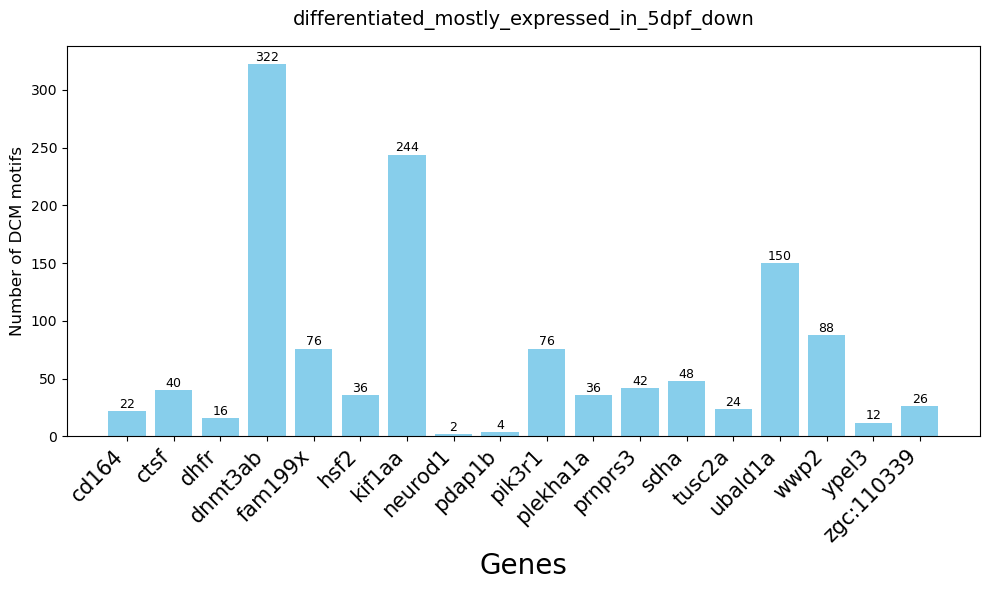

In [17]:
x = gene_motifs_count['Gene']
y = gene_motifs_count['Motif_count']
plt.figure(figsize=(10, 6)) 
bars = plt.bar(x, y, color='skyblue')
plt.xlabel('Genes', fontsize=20)
plt.ylabel('Number of DCM motifs', fontsize=12)
plt.title(f'{condition}', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize = 15)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,  # x position (center of bar)
        height + 0.1,                       # y position (slightly above bar)
        f'{height:.0f}',                    # text (value formatted without decimals)
        ha='center',                        # horizontal alignment
        va='bottom',                        # vertical alignment
        fontsize=9                          # text size
    )

plt.tight_layout()
plt.show()

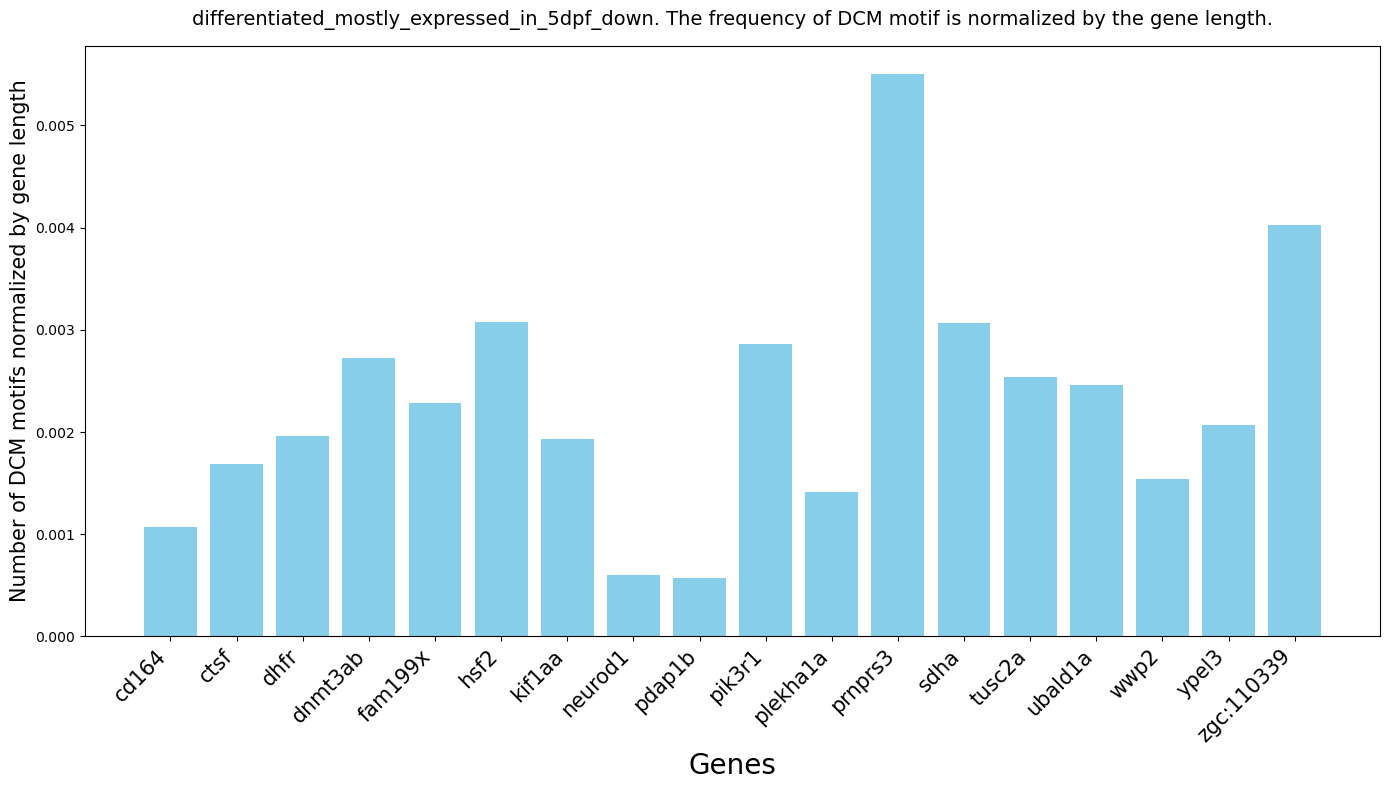

In [18]:
x = gene_motifs_count['Gene']
y = gene_motifs_count['Normalized_motif_count']

plt.figure(figsize=(14, 8)) 
plt.bar(x,y, color='skyblue') 

plt.xlabel('Genes', fontsize=20)
plt.ylabel('Number of DCM motifs normalized by gene length', fontsize=15)
plt.title(f'{condition}. The frequency of DCM motif is normalized by the gene length.', fontsize=14, pad=15)

plt.xticks(rotation=45, ha='right', fontsize = 15)
plt.tight_layout()

plt.show()